In [2]:
!pip install nycflights13

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from nycflights13 import flights

c:\Users\DS\anaconda3\envs\datascience\Lib\site-packages\nycflights13\__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename as _rf


추정할 변수 선택 및 결측치 제거

In [4]:
df=flights
data=df['dep_delay'].dropna()

모평균 구하기

In [5]:
population_mean=data.mean()
print('모집단 평균: ', round(population_mean, 2))

모집단 평균:  12.64


무작위 추출로 선택한 표본 데이터(100개)로 점 추정

In [6]:
random_sample = data.sample(n=100, random_state=42)
random_sample_mean = random_sample.mean()
print("점추정(표본평균):", round(random_sample_mean, 2))

점추정(표본평균): 13.32


무작위 추출로 선택한 표본 데이터(100개)로 점 추정 시각화

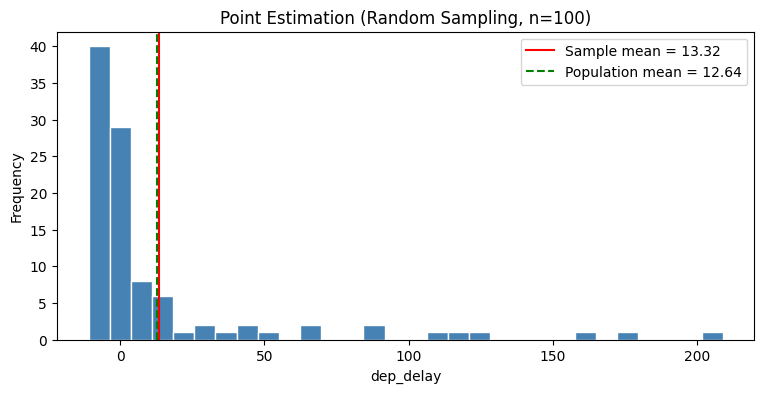

In [7]:
plt.figure(figsize=(9, 4))
plt.hist(random_sample, bins=30, color="steelblue", edgecolor="white")
plt.axvline(random_sample_mean, color="red", label=f"Sample mean = {random_sample_mean:.2f}")
plt.axvline(population_mean, color="green", linestyle="--", label=f"Population mean = {population_mean:.2f}")
plt.title(f"Point Estimation (Random Sampling, n={100})")
plt.xlabel("dep_delay")
plt.ylabel("Frequency")
plt.legend()
plt.show()

무작위 추출로 선택한 표본 데이터(100개)로 신뢰도 95% 구간 추정

In [8]:
random_sample_std = random_sample.std()
z = norm.ppf(1 - (1 - 0.95) / 2)
lower = random_sample_mean - z * (random_sample_std / (100 ** 0.5))
upper = random_sample_mean + z * (random_sample_std / (100 ** 0.5))
print(f"{int(0.95 * 100)}% 구간추정:", round(lower, 2), "~", round(upper, 2))

95% 구간추정: 5.37 ~ 21.27


무작위 추출로 선택한 표본 데이터(100개)로 신뢰도 95% 구간 추정 시각화

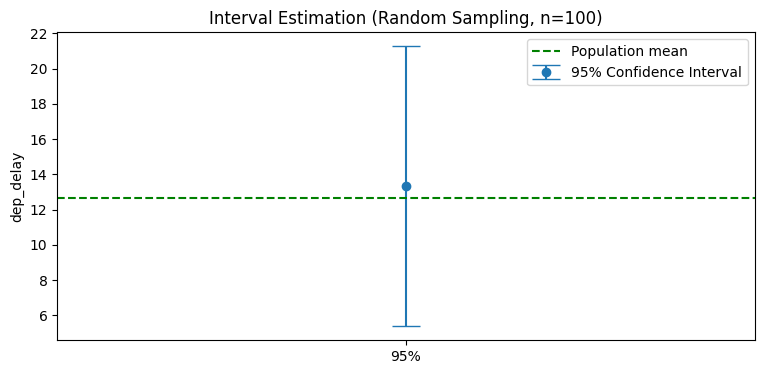

In [9]:
plt.figure(figsize=(9, 4))
x_pos = 0
plt.errorbar(
    x_pos,
    random_sample_mean,
    yerr=[[random_sample_mean - lower], [upper - random_sample_mean]],
    fmt="o",
    capsize=10,
    label=f"{int(0.95 * 100)}% Confidence Interval",
)
plt.axhline(population_mean, color="green", linestyle="--", label="Population mean")
plt.xticks([x_pos], [f"{int(0.95 * 100)}%"])
plt.title(f"Interval Estimation (Random Sampling, n={100})")
plt.ylabel("dep_delay")
plt.legend()
plt.show()

• 반복문을 사용하여 점추정과 구간추정 계산 및 시각화  
✓ 표본크기: 100, 1000, 10000 설정  
✓ 신뢰도: 99%, 95%, 90% 설정  
  
• 데이터에서 항공사별 비율을 유지한 채로 표본을 추출하는 계층화 추출을 적용하여 점추정과 구간추정 계산 및 시각화

In [10]:
df_clean = df[["dep_delay", "carrier"]].dropna()

sample_list = []
for carrier in df_clean["carrier"].unique():
    group = df_clean[df_clean["carrier"] == carrier]
    k = round(len(group) / len(df_clean) * 100)
    if k > 0:
        part = group.sample(n=min(k, len(group)), random_state=42)
        sample_list.append(part)

stratified_sample = pd.concat(sample_list)["dep_delay"]

=== [표본 크기: 100 / 신뢰도: 99%] ===
점추정(표본평균): 13.32
구간추정(99% 신뢰구간): 2.88 ~ 23.76



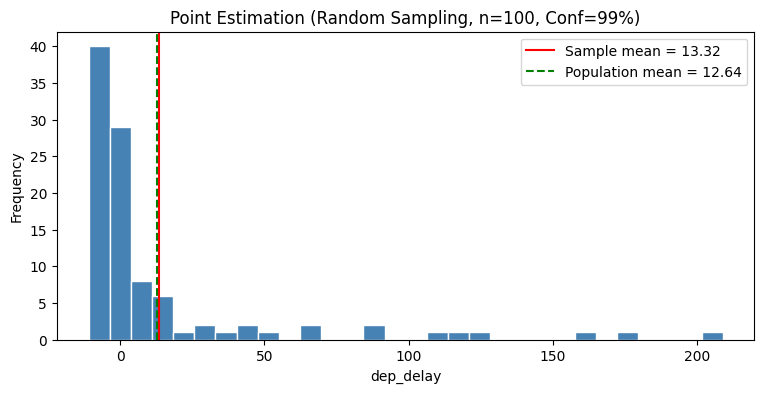

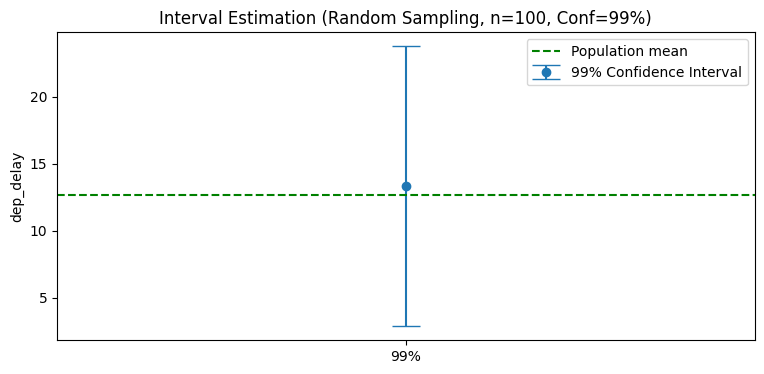

=== [표본 크기: 100 / 신뢰도: 95%] ===
점추정(표본평균): 13.32
구간추정(95% 신뢰구간): 5.37 ~ 21.27



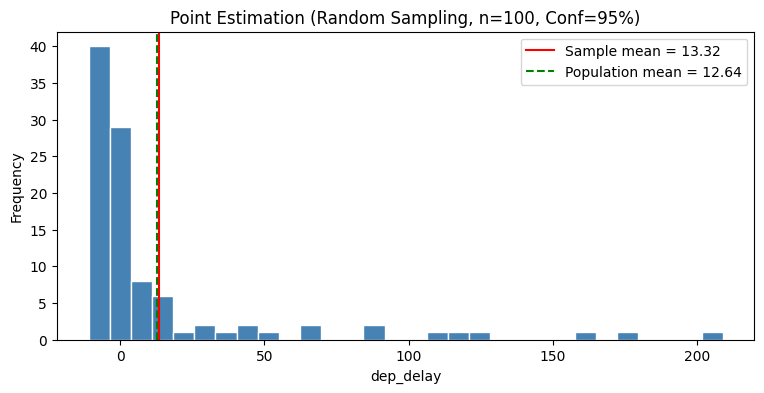

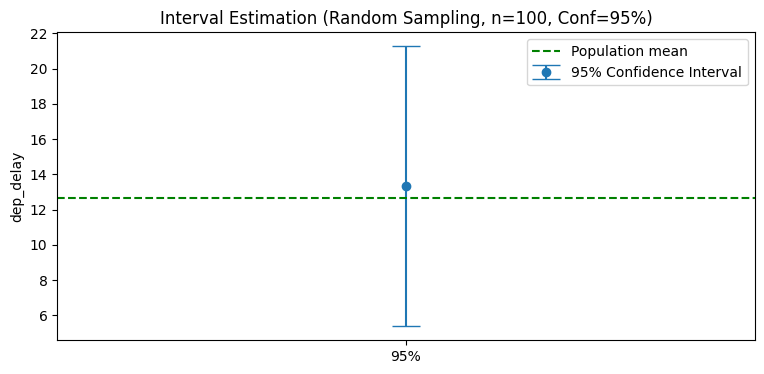

=== [표본 크기: 100 / 신뢰도: 90%] ===
점추정(표본평균): 13.32
구간추정(90% 신뢰구간): 6.65 ~ 19.99



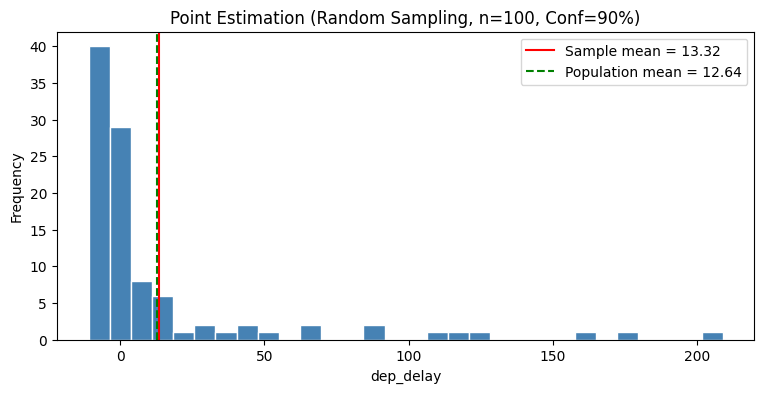

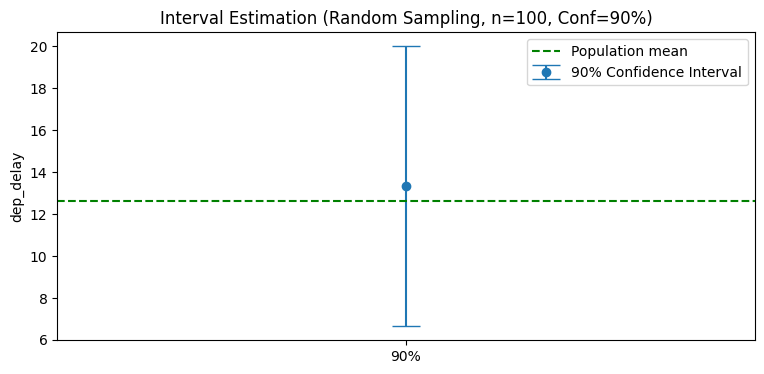

=== [표본 크기: 1000 / 신뢰도: 99%] ===
점추정(표본평균): 13.12
구간추정(99% 신뢰구간): 9.81 ~ 16.44



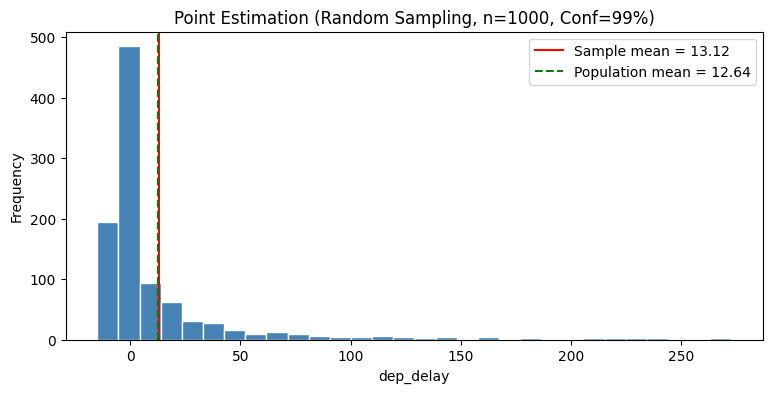

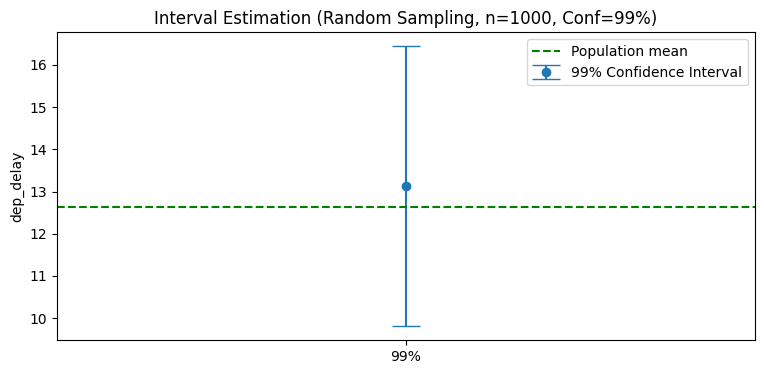

=== [표본 크기: 1000 / 신뢰도: 95%] ===
점추정(표본평균): 13.12
구간추정(95% 신뢰구간): 10.60 ~ 15.65



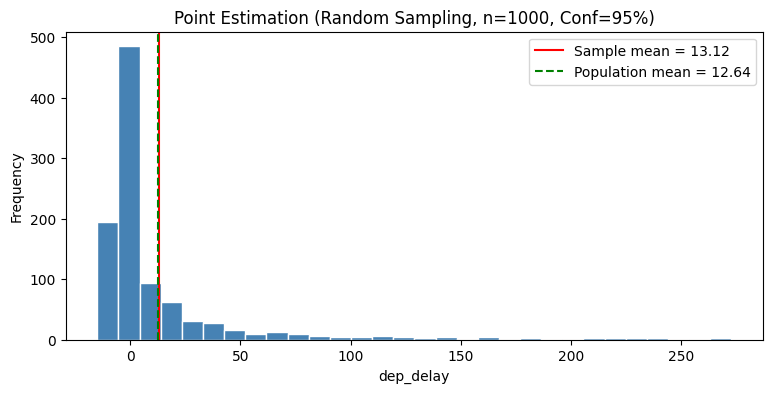

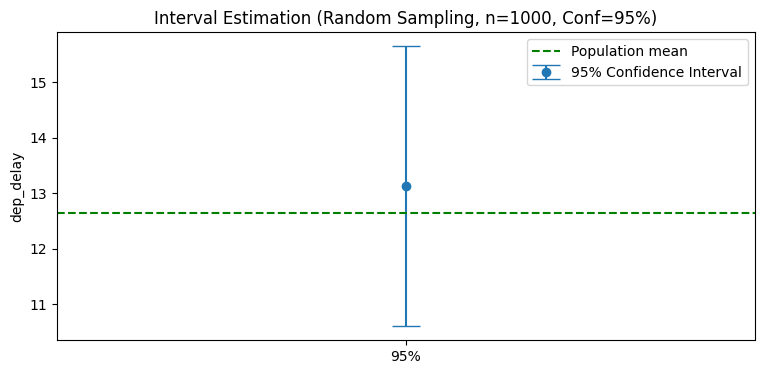

=== [표본 크기: 1000 / 신뢰도: 90%] ===
점추정(표본평균): 13.12
구간추정(90% 신뢰구간): 11.01 ~ 15.24



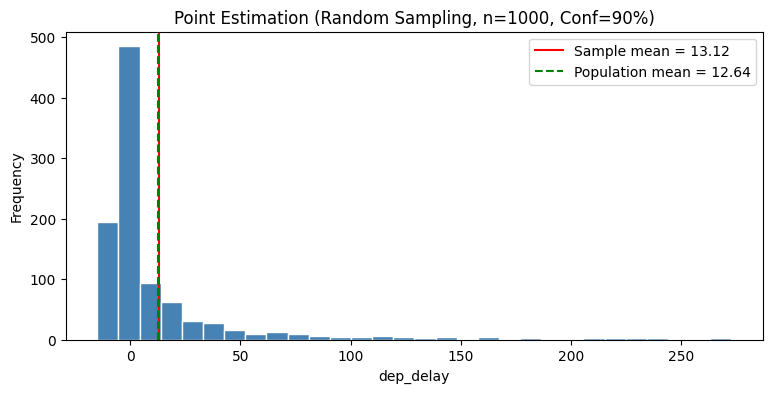

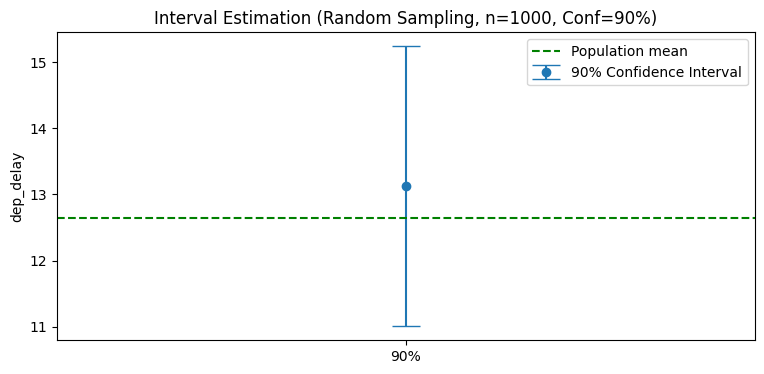

=== [표본 크기: 10000 / 신뢰도: 99%] ===
점추정(표본평균): 12.47
구간추정(99% 신뢰구간): 11.45 ~ 13.49



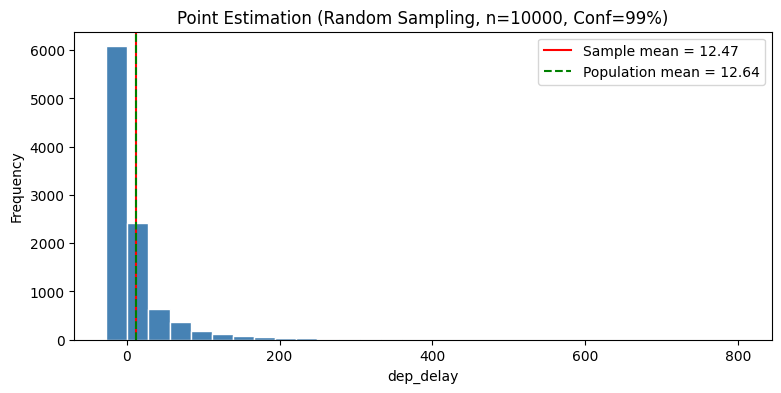

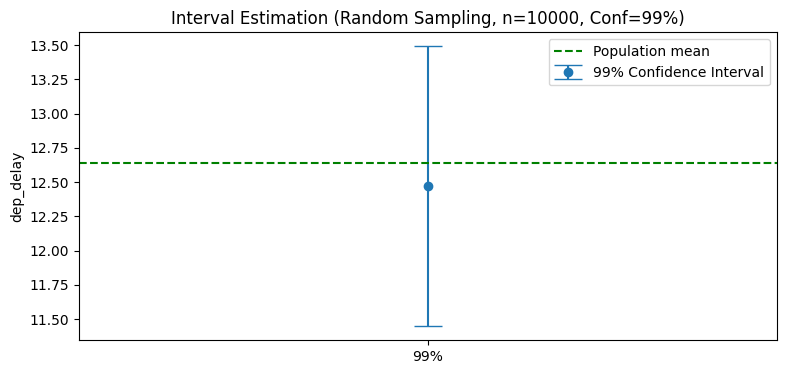

=== [표본 크기: 10000 / 신뢰도: 95%] ===
점추정(표본평균): 12.47
구간추정(95% 신뢰구간): 11.69 ~ 13.25



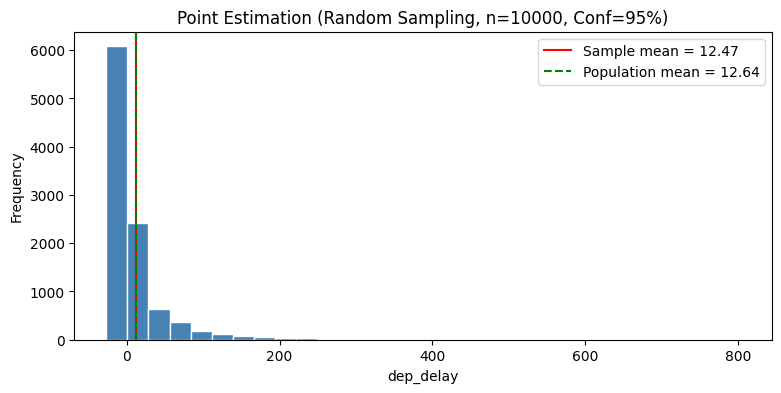

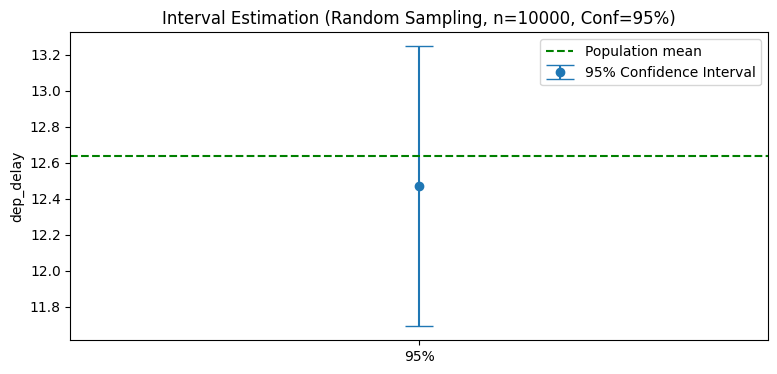

=== [표본 크기: 10000 / 신뢰도: 90%] ===
점추정(표본평균): 12.47
구간추정(90% 신뢰구간): 11.82 ~ 13.12



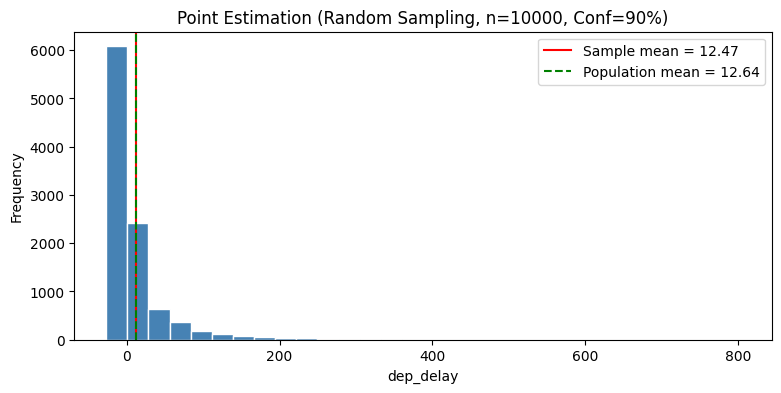

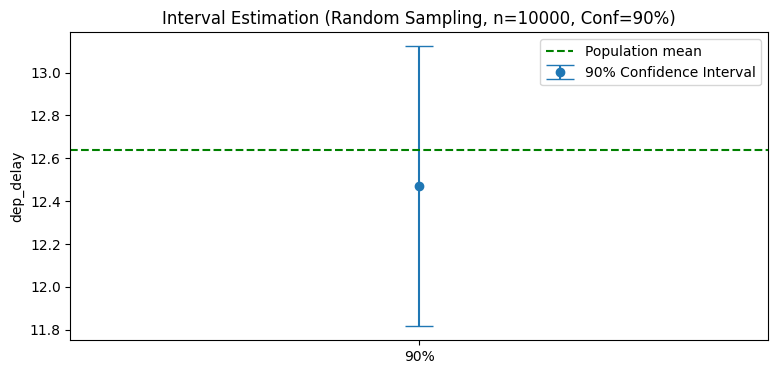

In [11]:
sample_sizes = [100, 1000, 10000]
confidence_levels = [0.99, 0.95, 0.90]

for n in sample_sizes:
    for conf in confidence_levels:
        # 무작위 표본 추출 및 점추정
        random_sample = data.sample(n=n, random_state=42)
        random_sample_mean = random_sample.mean()
        random_sample_std = random_sample.std()
        
        # 구간 추정 (Z-값 및 신뢰구간 계산)
        z = norm.ppf(1 - (1 - conf) / 2)
        lower = random_sample_mean - z * (random_sample_std / (n ** 0.5))
        upper = random_sample_mean + z * (random_sample_std / (n ** 0.5))
        
        print(f"=== [표본 크기: {n} / 신뢰도: {int(conf*100)}%] ===")
        print(f"점추정(표본평균): {random_sample_mean:.2f}")
        print(f"구간추정({int(conf*100)}% 신뢰구간): {lower:.2f} ~ {upper:.2f}\n")
        
        # 점추정 시각화 (히스토그램)
        plt.figure(figsize=(9, 4))
        plt.hist(random_sample, bins=30, color="steelblue", edgecolor="white")
        plt.axvline(random_sample_mean, color="red", label=f"Sample mean = {random_sample_mean:.2f}")
        plt.axvline(population_mean, color="green", linestyle="--", label=f"Population mean = {population_mean:.2f}")
        plt.title(f"Point Estimation (Random Sampling, n={n}, Conf={int(conf*100)}%)")
        plt.xlabel("dep_delay")
        plt.ylabel("Frequency")
        plt.legend()
        plt.show()
        
        # 구간추정 시각화
        plt.figure(figsize=(9, 4))
        x_pos = 0
        plt.errorbar(
            x_pos,
            random_sample_mean,
            yerr=[[random_sample_mean - lower], [upper - random_sample_mean]],
            fmt="o",
            capsize=10,
            label=f"{int(conf * 100)}% Confidence Interval",
        )
        plt.axhline(population_mean, color="green", linestyle="--", label="Population mean")
        plt.xticks([x_pos], [f"{int(conf * 100)}%"])
        plt.title(f"Interval Estimation (Random Sampling, n={n}, Conf={int(conf*100)}%)")
        plt.ylabel("dep_delay")
        plt.legend()
        plt.show()

=== [계층화 추출 - 표본 크기: 101 / 신뢰도: 99%] ===
점추정(계층화 표본평균): 9.63
구간추정(신뢰구간): 2.54 ~ 16.73



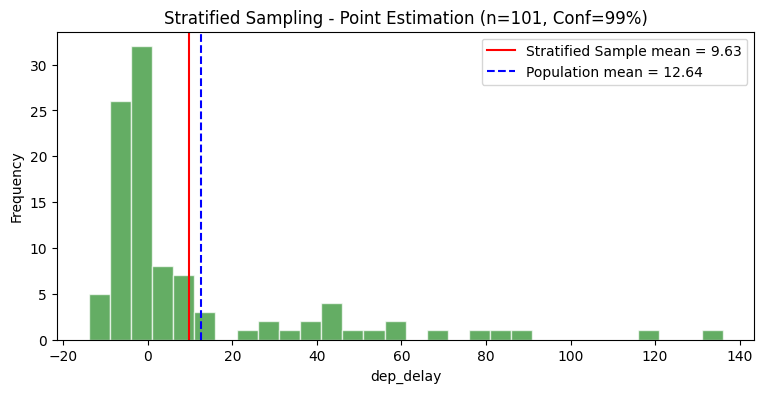

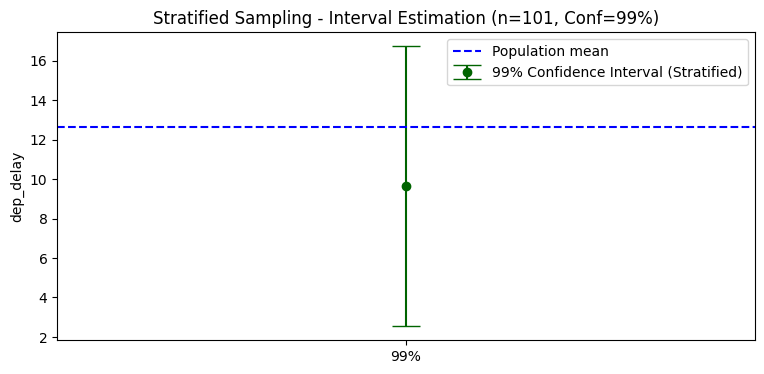

=== [계층화 추출 - 표본 크기: 101 / 신뢰도: 95%] ===
점추정(계층화 표본평균): 9.63
구간추정(신뢰구간): 4.24 ~ 15.03



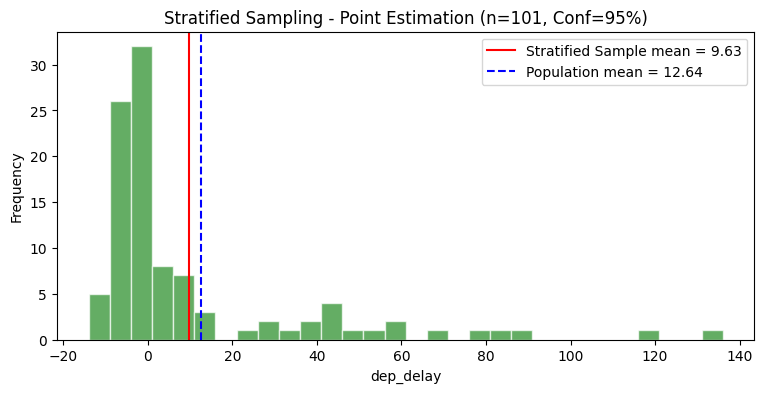

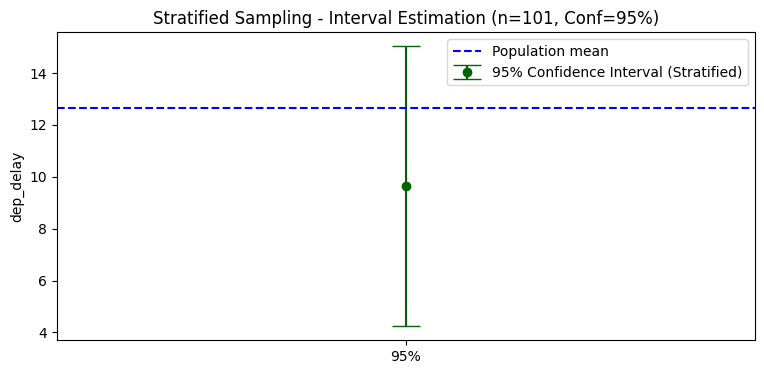

=== [계층화 추출 - 표본 크기: 101 / 신뢰도: 90%] ===
점추정(계층화 표본평균): 9.63
구간추정(신뢰구간): 5.11 ~ 14.16



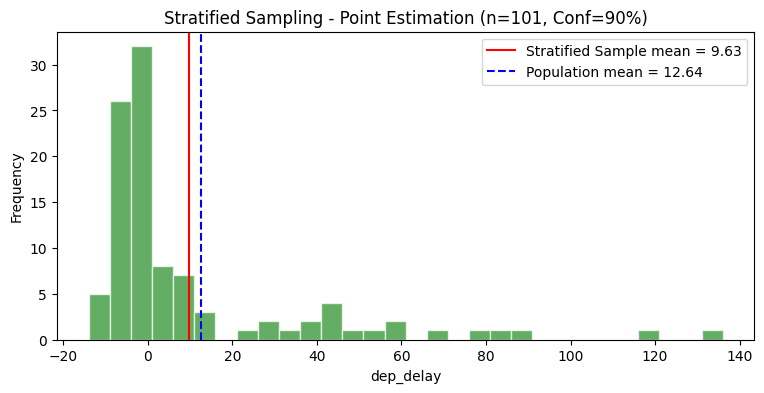

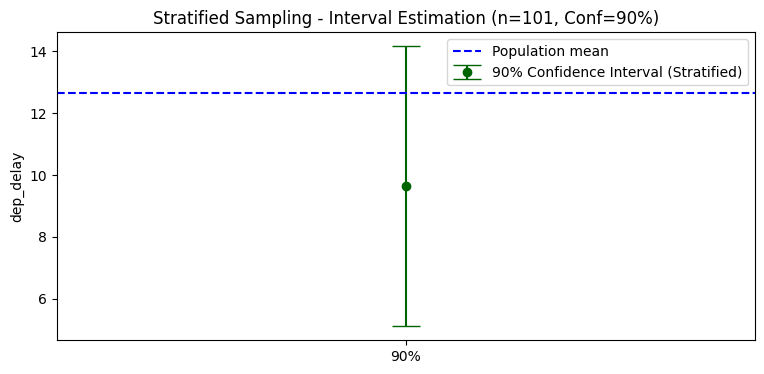

=== [계층화 추출 - 표본 크기: 1000 / 신뢰도: 99%] ===
점추정(계층화 표본평균): 13.37
구간추정(신뢰구간): 10.09 ~ 16.65



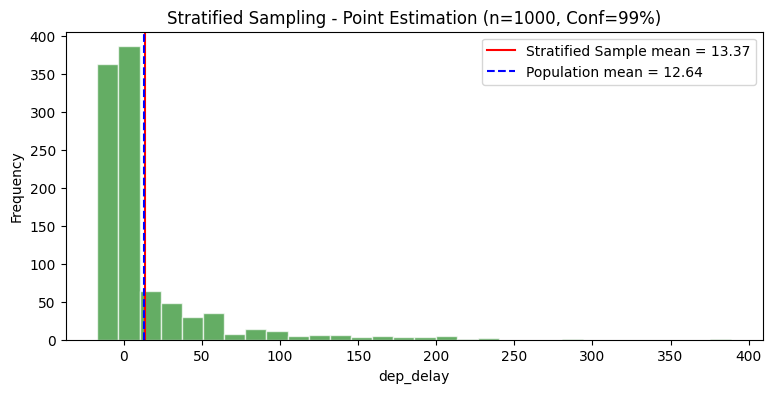

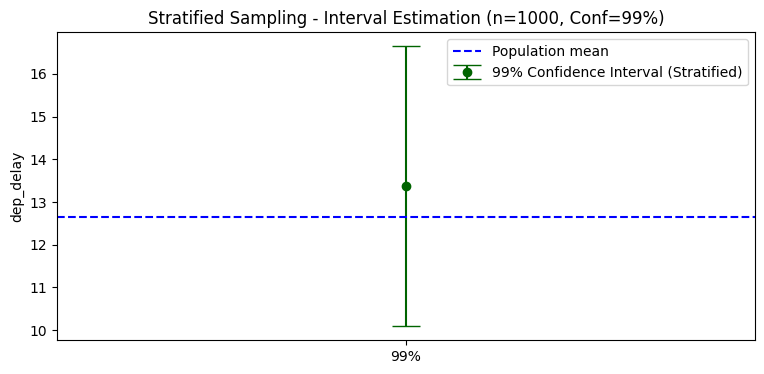

=== [계층화 추출 - 표본 크기: 1000 / 신뢰도: 95%] ===
점추정(계층화 표본평균): 13.37
구간추정(신뢰구간): 10.87 ~ 15.86



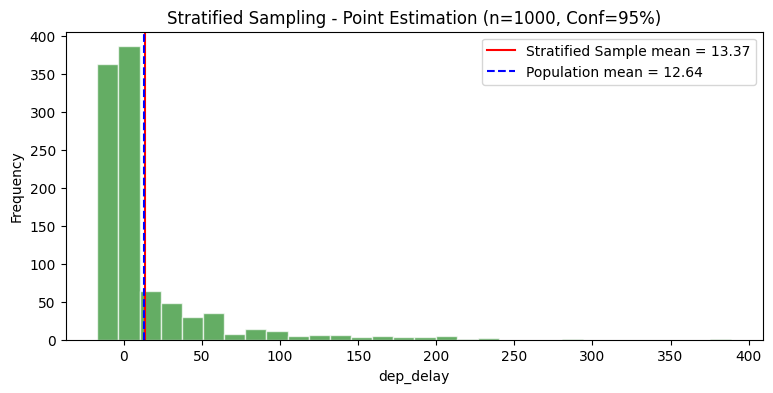

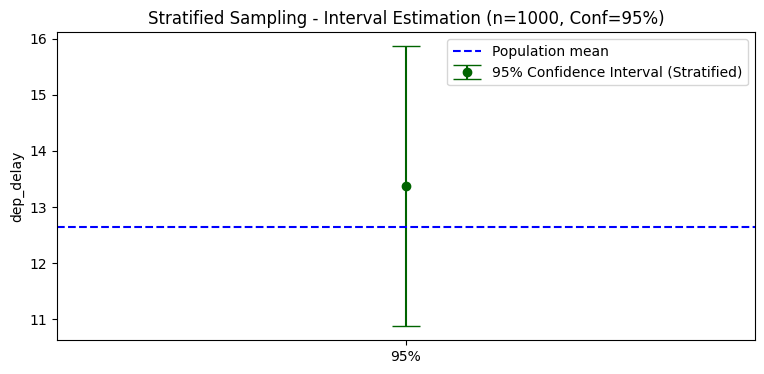

=== [계층화 추출 - 표본 크기: 1000 / 신뢰도: 90%] ===
점추정(계층화 표본평균): 13.37
구간추정(신뢰구간): 11.28 ~ 15.46



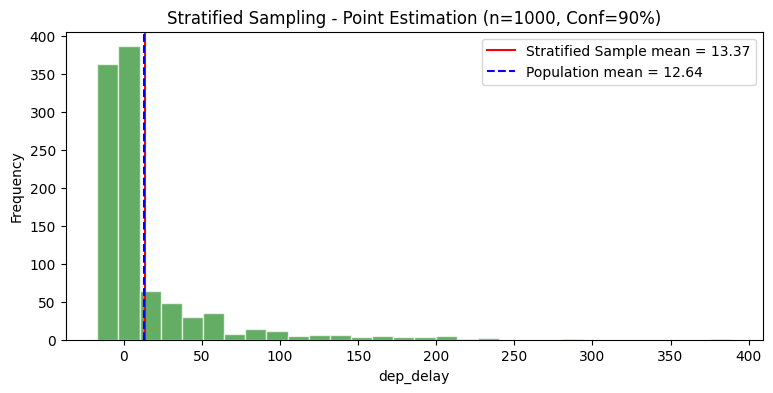

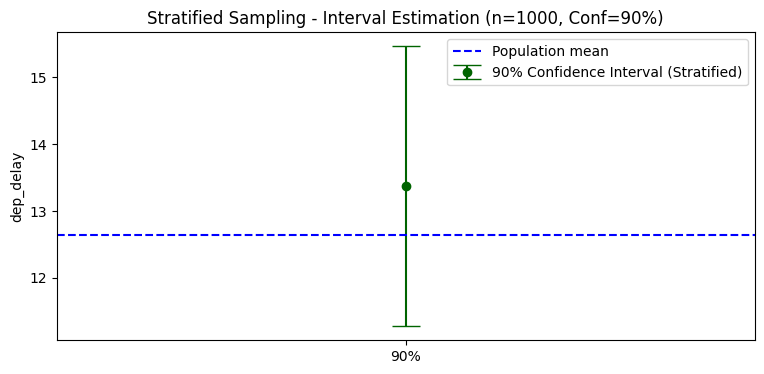

=== [계층화 추출 - 표본 크기: 10001 / 신뢰도: 99%] ===
점추정(계층화 표본평균): 12.86
구간추정(신뢰구간): 11.85 ~ 13.88



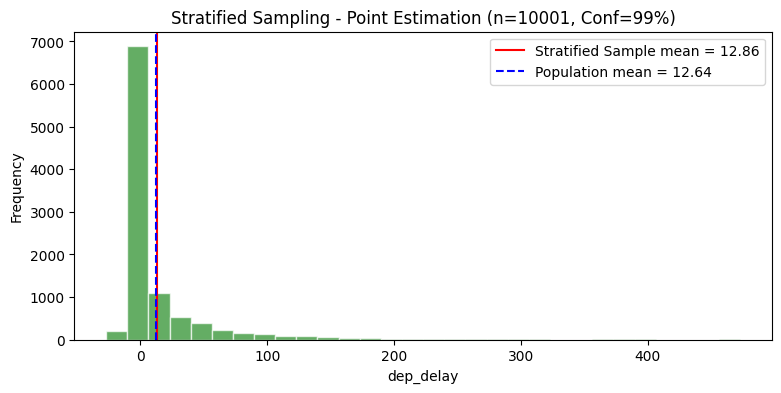

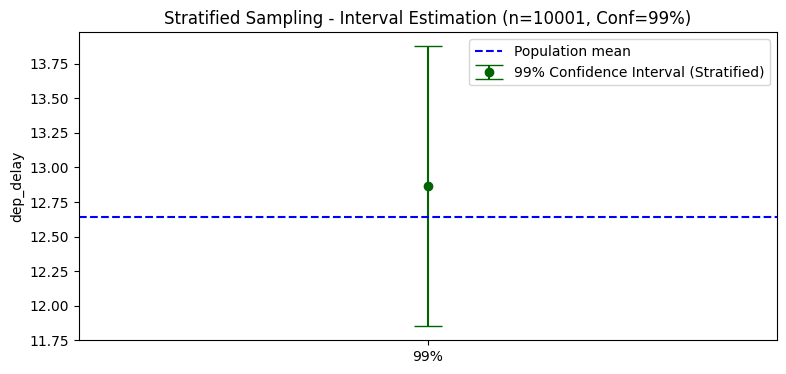

=== [계층화 추출 - 표본 크기: 10001 / 신뢰도: 95%] ===
점추정(계층화 표본평균): 12.86
구간추정(신뢰구간): 12.09 ~ 13.63



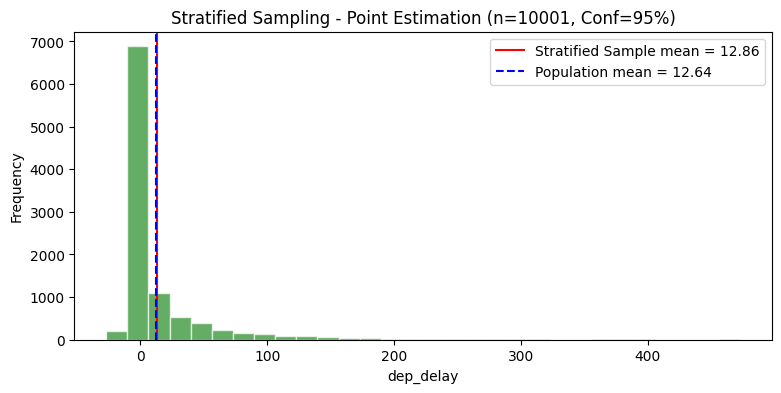

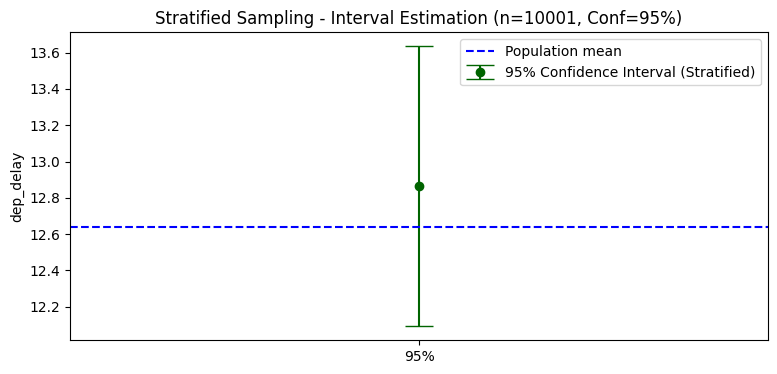

=== [계층화 추출 - 표본 크기: 10001 / 신뢰도: 90%] ===
점추정(계층화 표본평균): 12.86
구간추정(신뢰구간): 12.22 ~ 13.51



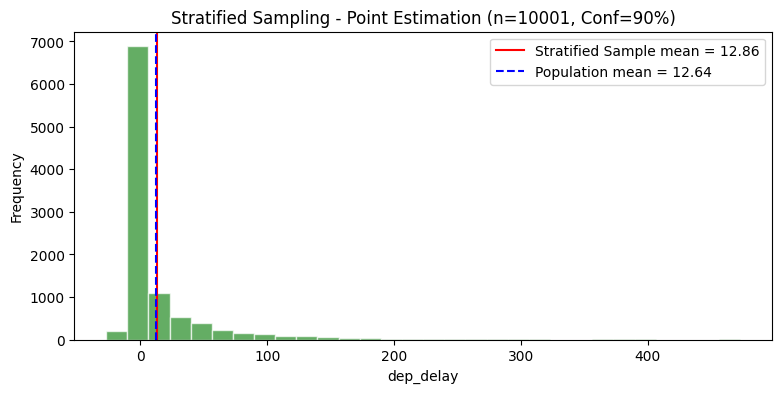

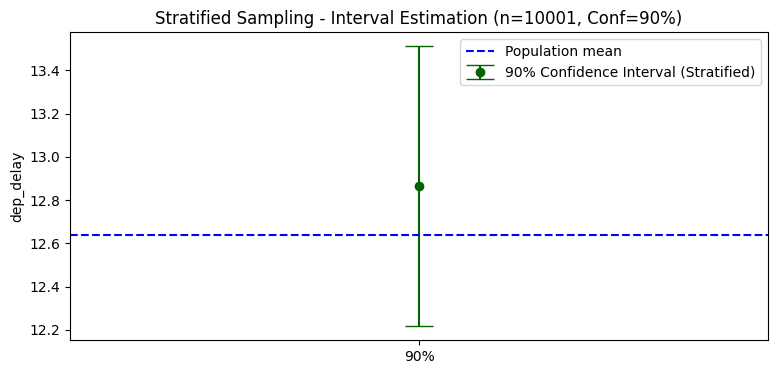

In [15]:
# 계층화 추출
for n in sample_sizes:
    for conf in confidence_levels:
        
        # 항공사별 비율을 유지하며 계층화 추출 수행
        sample_list = []
        for carrier in df_clean["carrier"].unique():
            group = df_clean[df_clean["carrier"] == carrier]
            # 현재 n(100, 1000, 10000) 비율에 맞게 항공사별 추출 개수 결정
            k = round(len(group) / len(df_clean) * n)
            if k > 0:
                part = group.sample(n=min(k, len(group)), random_state=42)
                sample_list.append(part)

        stratified_sample_df = pd.concat(sample_list)
        stratified_sample = stratified_sample_df["dep_delay"]
        n_strat = len(stratified_sample) # 실제 추출된 총 표본 크기

        # 점추정 및 구간추정 계산
        stratified_mean = stratified_sample.mean()
        stratified_std = stratified_sample.std()

        z_strat = norm.ppf(1 - (1 - conf) / 2)
        lower_strat = stratified_mean - z_strat * (stratified_std / (n_strat ** 0.5))
        upper_strat = stratified_mean + z_strat * (stratified_std / (n_strat ** 0.5))

        print(f"=== [계층화 추출 - 표본 크기: {n_strat} / 신뢰도: {int(conf*100)}%] ===")
        print(f"점추정(계층화 표본평균): {stratified_mean:.2f}")
        print(f"구간추정(신뢰구간): {lower_strat:.2f} ~ {upper_strat:.2f}\n")

        # 계층화 추출 점추정 시각화
        plt.figure(figsize=(9, 4))
        plt.hist(stratified_sample, bins=30, color="forestgreen", edgecolor="white", alpha=0.7)
        plt.axvline(stratified_mean, color="red", label=f"Stratified Sample mean = {stratified_mean:.2f}")
        plt.axvline(population_mean, color="blue", linestyle="--", label=f"Population mean = {population_mean:.2f}")
        plt.title(f"Stratified Sampling - Point Estimation (n={n_strat}, Conf={int(conf*100)}%)")
        plt.xlabel("dep_delay")
        plt.ylabel("Frequency")
        plt.legend()
        plt.show()

        # 계층화 추출 구간추정 시각화
        plt.figure(figsize=(9, 4))
        x_pos = 0
        plt.errorbar(
            x_pos,
            stratified_mean,
            yerr=[[stratified_mean - lower_strat], [upper_strat - stratified_mean]],
            fmt="o",
            capsize=10,
            color="darkgreen",
            label=f"{int(conf * 100)}% Confidence Interval (Stratified)",
        )
        plt.axhline(population_mean, color="blue", linestyle="--", label="Population mean")
        plt.xticks([x_pos], [f"{int(conf * 100)}%"])
        plt.title(f"Stratified Sampling - Interval Estimation (n={n_strat}, Conf={int(conf*100)}%)")
        plt.ylabel("dep_delay")
        plt.legend()
        plt.show()